<a href="https://colab.research.google.com/github/Priyall33/Pcos-Endometrosis-risk-model/blob/main/04_Model_1__NHANES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04 — Model 1: Hormone Risk Model (NHANES)


This notebook trains the first of two XGBoost models using CDC NHANES hormone blood test data. This is the **primary model** in our two-model architecture.

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

drive.mount('/content/drive')
os.makedirs('outputs', exist_ok=True)

!pip install imbalanced-learn -q

print("✅ Setup complete!")

Mounted at /content/drive
✅ Setup complete!


In [2]:
save_dir = '/content/drive/MyDrive/model_data/'

# Load NHANES splits
X_train = pd.read_csv(f'{save_dir}nhanes_X_train.csv')
X_test  = pd.read_csv(f'{save_dir}nhanes_X_test.csv')
y_train = pd.read_csv(f'{save_dir}nhanes_y_train.csv').squeeze()
y_test  = pd.read_csv(f'{save_dir}nhanes_y_test.csv').squeeze()


print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

print(f"\nTraining label distribution (before SMOTE):")
print(y_train.value_counts())
print(f"Positive rate: {y_train.mean()*100:.1f}%")

print(f"\nFeatures:")
for col in X_train.columns:
    missing = X_train[col].isna().mean() * 100
    print(f"  {col:<15} — {missing:.1f}% missing")

X_train : (9075, 11)
X_test  : (2269, 11)
y_train : (9075,)
y_test  : (2269,)

Training label distribution (before SMOTE):
endometriosis
0    8013
1    1062
Name: count, dtype: int64
Positive rate: 11.7%

Features:
  LBXAMH          — 70.5% missing
  LBXFSH          — 70.6% missing
  LBXLUH          — 70.5% missing
  LBXSHBG         — 31.2% missing
  LBXAND          — 70.5% missing
  LBXEST          — 30.4% missing
  LBXPG4          — 70.7% missing
  RHQ010          — 0.0% missing
  RHQ131          — 0.2% missing
  RHQ160          — 68.8% missing
  cycle           — 0.0% missing


In [3]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer


print(f"Before SMOTE:")
print(f"  Negative: {(y_train==0).sum():,}")
print(f"  Positive: {(y_train==1).sum():,}")

#imputer for missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

smote = SMOTE(random_state=42)


X_train_balanced, y_train_balanced = smote.fit_resample(X_train_imputed, y_train) # Use X_train_imputed here

print(f"\nAfter SMOTE:")
print(f"  Negative: {(y_train_balanced==0).sum():,}")
print(f"  Positive: {(y_train_balanced==1).sum():,}")
print(f"  Total   : {len(y_train_balanced):,}")
print(f"  Positive rate: {y_train_balanced.mean()*100:.1f}%")


Before SMOTE:
  Negative: 8,013
  Positive: 1,062

After SMOTE:
  Negative: 8,013
  Positive: 8,013
  Total   : 16,026
  Positive rate: 50.0%


NOTE ON MISSING DATA HANDLING:
SMOTE cannot interpolate between rows that contain NaN values
Solution: temporarily fill NaN with column median ONLY for SMOTE

Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_balanced, y_train_balanced)

# Apply the SAME imputer fitted on training data — never refit on test data
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

lr_probs = lr.predict_proba(X_test_imputed)[:, 1]
lr_preds = lr.predict(X_test_imputed)

lr_auc  = roc_auc_score(y_test, lr_probs)
lr_f1   = f1_score(y_test, lr_preds)
lr_rec  = recall_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds)

print(f"\nLOGISTIC REGRESSION RESULTS")
print(f"  AUC-ROC  : {lr_auc:.4f}  (target: 0.70+)")
print(f"  Recall   : {lr_rec:.4f}  (target: 0.80+)")
print(f"  Precision: {lr_prec:.4f}")
print(f"  F1 Score : {lr_f1:.4f}")
print(f"\nFull breakdown:")
print(classification_report(y_test, lr_preds, target_names=["No PCOS/Endo", "PCOS/Endo"]))


LOGISTIC REGRESSION RESULTS
  AUC-ROC  : 0.7029  (target: 0.70+)
  Recall   : 0.7895  (target: 0.80+)
  Precision: 0.1699
  F1 Score : 0.2796

Full breakdown:
              precision    recall  f1-score   support

No PCOS/Endo       0.95      0.49      0.64      2003
   PCOS/Endo       0.17      0.79      0.28       266

    accuracy                           0.52      2269
   macro avg       0.56      0.64      0.46      2269
weighted avg       0.85      0.52      0.60      2269



XGBoost

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, classification_report
import numpy as np

# Fill NaN temporarily so SMOTE can run
X_train_filled = X_train.fillna(X_train.median())
smote2 = SMOTE(random_state=42)
X_train_xgb, y_train_xgb = smote2.fit_resample(X_train_filled, y_train)
X_train_xgb = pd.DataFrame(X_train_xgb, columns=X_train.columns)

# Restore NaN pattern for the original rows so XGBoost handles them natively
nan_mask = X_train.isnull().values
original_size = X_train.shape[0]
for i, col in enumerate(X_train.columns):
    col_mask = nan_mask[:, i]
    X_train_xgb.loc[:original_size-1, col] = np.where(
        col_mask,
        np.nan,
        X_train_xgb.loc[:original_size-1, col]
    )

#Train XGBoost
xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    eval_metric='logloss',
    random_state=42
)

xgb2.fit(X_train_xgb, y_train_xgb)

#Predict on raw X_test XGBoost handles NaN natively
xgb2_probs = xgb2.predict_proba(X_test)[:, 1]

# threshold 0.30
# missing a high-risk woman is far more costly
FINAL_THRESHOLD = 0.30
xgb2_preds = (xgb2_probs >= FINAL_THRESHOLD).astype(int)

xgb2_auc  = roc_auc_score(y_test, xgb2_probs)
xgb2_f1   = f1_score(y_test, xgb2_preds)
xgb2_rec  = recall_score(y_test, xgb2_preds)
xgb2_prec = precision_score(y_test, xgb2_preds)

print(f"\n XGBOOST RESULTS")
print(f"  AUC-ROC  : {xgb2_auc:.4f}")
print(f"  Recall   : {xgb2_rec:.4f}")
print(f"  Precision: {xgb2_prec:.4f}")
print(f"  F1 Score : {xgb2_f1:.4f}")
print(f"\nFull breakdown:")
print(classification_report(y_test, xgb2_preds, target_names=["No PCOS/Endo", "PCOS/Endo"]))


 XGBOOST RESULTS
  AUC-ROC  : 0.6953
  Recall   : 0.8083
  Precision: 0.1696
  F1 Score : 0.2803

Full breakdown:
              precision    recall  f1-score   support

No PCOS/Endo       0.95      0.47      0.63      2003
   PCOS/Endo       0.17      0.81      0.28       266

    accuracy                           0.51      2269
   macro avg       0.56      0.64      0.46      2269
weighted avg       0.86      0.51      0.59      2269



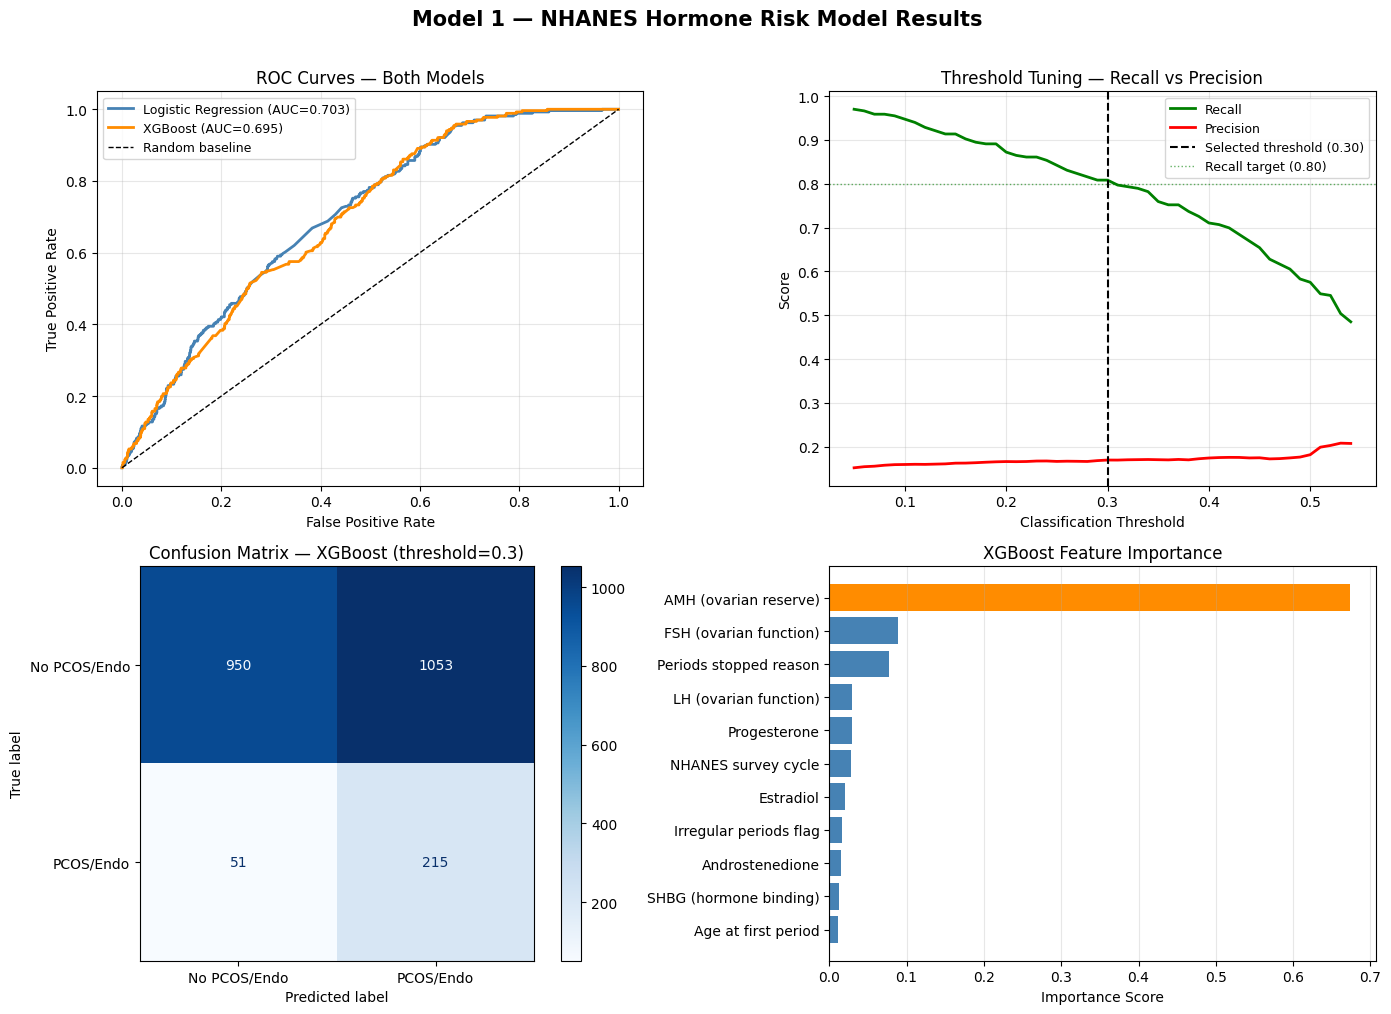

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model 1 — NHANES Hormone Risk Model Results", fontsize=15, fontweight='bold', y=1.01)

# ROC Curves
ax1 = axes[0, 0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb2_probs)

ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', color='steelblue', lw=2)
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb2_auc:.3f})', color='darkorange', lw=2)
ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — Both Models')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

#Threshold vs Recall/Precision
ax2 = axes[0, 1]
thresholds = np.arange(0.05, 0.55, 0.01)
recalls, precisions = [], []
for t in thresholds:
    p = (xgb2_probs >= t).astype(int)
    recalls.append(recall_score(y_test, p))
    precisions.append(precision_score(y_test, p))

ax2.plot(thresholds, recalls, label='Recall', color='green', lw=2)
ax2.plot(thresholds, precisions, label='Precision', color='red', lw=2)
ax2.axvline(x=0.30, color='black', linestyle='--', lw=1.5, label='Selected threshold (0.30)')
ax2.axhline(y=0.80, color='green', linestyle=':', lw=1, alpha=0.6, label='Recall target (0.80)')
ax2.set_xlabel('Classification Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Threshold Tuning — Recall vs Precision')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Confusion Matrix
ax3 = axes[1, 0]
ConfusionMatrixDisplay.from_predictions(
    y_test, xgb2_preds,
    display_labels=["No PCOS/Endo", "PCOS/Endo"],
    cmap='Blues',
    ax=ax3
)
ax3.set_title(f'Confusion Matrix — XGBoost (threshold={FINAL_THRESHOLD})')

# Feature Importance
ax4 = axes[1, 1]
feat_imp = pd.Series(xgb2.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

# Readable labels for the NHANES
label_map = {
    'LBXAMH' : 'AMH (ovarian reserve)',
    'LBXFSH' : 'FSH (ovarian function)',
    'LBXLUH' : 'LH (ovarian function)',
    'LBXSHBG': 'SHBG (hormone binding)',
    'LBXAND' : 'Androstenedione',
    'LBXEST' : 'Estradiol',
    'LBXPG4' : 'Progesterone',
    'RHQ010' : 'Age at first period',
    'RHQ131' : 'Irregular periods flag',
    'RHQ160' : 'Periods stopped reason',
    'cycle'  : 'NHANES survey cycle'
}
feat_imp_sorted.index = [label_map.get(i, i) for i in feat_imp_sorted.index]

colors = ['steelblue' if v < feat_imp_sorted.max() * 0.5 else 'darkorange' for v in feat_imp_sorted]
ax4.barh(feat_imp_sorted.index, feat_imp_sorted.values, color=colors)
ax4.set_xlabel('Importance Score')
ax4.set_title('XGBoost Feature Importance')
ax4.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('outputs/model1_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
import joblib

print("  FINAL MODEL 1 RESULTS — NHANES Hormone Model")


summary = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'XGBoost (threshold=0.30)'],
    'AUC-ROC' : [lr_auc,   xgb2_auc],
    'Recall'  : [lr_rec,   xgb2_rec],
    'Precision': [lr_prec, xgb2_prec],
    'F1'      : [lr_f1,    xgb2_f1]
}).set_index('Model').round(4)

print(summary)

# Save model artifacts for SHAP
joblib.dump(xgb2, 'outputs/xgb_nhanes_model.pkl')
joblib.dump(FINAL_THRESHOLD, 'outputs/xgb_nhanes_threshold.pkl')
X_test.to_csv('outputs/X_test_nhanes.csv', index=False)
y_test.to_csv('outputs/y_test_nhanes.csv', index=False)


  FINAL MODEL 1 RESULTS — NHANES Hormone Model
                                AUC-ROC  Recall  Precision      F1
Model                                                             
Logistic Regression (baseline)   0.7029  0.7895     0.1699  0.2796
XGBoost (threshold=0.30)         0.6953  0.8083     0.1696  0.2803
